# Deep Operator Network (DeepONets) in Neuromancer: Learning nonlinear operators

Recreating TI-DeepONet Heat equation notebook from (https://github.com/Centrum-IntelliPhysics/PDEControl_DPC/tree/main)

<!-- <img src="https://github.com/Centrum-IntelliPhysics/PDEControl_DPC/blob/main/DPC_NO.png" width="700"> -->
<img src="https://github.com/Centrum-IntelliPhysics/PDEControl_DPC/blob/main/DPC_NO.png?raw=true" width="700"> 

### References

[1] [Sarkar, D. R., Drgoňa, J., & Goswami, S. (2025). Learning to Control PDEs with Differentiable Predictive Control and Time-Integrated Neural Operators. arXiv preprint arXiv:2511.08992.](https://arxiv.org/pdf/2511.08992)


### Install (Colab only)

In [1]:
# %pip install "neuromancer[examples] @ git+https://github.com/pnnl/neuromancer.git@master"
# %pip install watermark

### Imports

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn


In [2]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random seed
seed = 1234
torch.manual_seed(seed)
# NumPy random seed
np.random.seed(seed)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


## Dataset Prep

In [4]:
data_path = "/home/pk222/projects/PDEControl_DPC/datasets/heat_smooth_f_dataset.npz"
# result_dir = './'
# epochs = int(500)
# log_iter = 5
# lr = 1e-3
# transition_steps = 2000
# decay_rate = 0.9

In [ ]:
dataset = np.load(data_path)  # total 3000 samples
samples_to_load = 300

solutions = torch.from_numpy(
    dataset["solutions"][:samples_to_load]
)  # shape: (samples, T+1, N)
controls = torch.from_numpy(
    dataset["controls"][:samples_to_load]
)  # shape: (samples, T, 2)
x_cord = torch.from_numpy(dataset["x"]).reshape(-1, 1)  # shape: (N, 1)
dt = dataset["dt"]  # likely a scalar numpy value

print(f"Loaded {samples_to_load}/{dataset['solutions'].shape[0]} samples:")
print("solutions:", solutions.shape)
print("controls:", controls.shape)
print("x:", x_cord.shape)
print("dt:", dt)

Loaded 300/3000 samples:
solutions: torch.Size([300, 401, 100])
controls: torch.Size([300, 400, 4])
x: torch.Size([100, 1])
dt: 0.001


In [6]:
# Slice u_t and u_{t+1}
u_t = solutions[:, :-1, :]  # (samples, T, N)
u_next = solutions[:, 1:, :]  # (samples, T, N)
f_t = controls[:, :, :]  # (samples, T, 2)

print("u_t: ", str(u_t.shape))
print("u_next: ", str(u_next.shape))
print("f_t: ", str(f_t.shape))


u_t:  torch.Size([300, 400, 100])
u_next:  torch.Size([300, 400, 100])
f_t:  torch.Size([300, 400, 4])


In [7]:
# flatten (samples × time)
branch_x1 = u_t.reshape(-1, u_t.shape[-1])  # (N, 100)
branch_x2 = f_t.reshape(-1, f_t.shape[-1])  # (N, 4)
outputs = u_next.reshape(-1, u_next.shape[-1])  # (N, 100)

print("branch_x1: ", str(branch_x1.shape))
print("branch_x2: ", str(branch_x2.shape))
print("outputs: ", str(outputs.shape))

branch_x1:  torch.Size([120000, 100])
branch_x2:  torch.Size([120000, 4])
outputs:  torch.Size([120000, 100])


In [8]:
# Shuffle indices
num_samples = branch_x1.shape[0]
g = torch.Generator().manual_seed(seed)
idx = torch.randperm(num_samples)

print("Shuffled indices: ", str(idx))

branch_x1 = branch_x1[idx]
branch_x2 = branch_x2[idx]
outputs = outputs[idx]

Shuffled indices:  tensor([ 89775,  26984,  61340,  ..., 110752,  31096, 104612])


In [9]:
# split
train_frac = 0.8  # percentage
n_train = int(train_frac * num_samples)

print("Number of training samples: ", n_train)

Number of training samples:  96000


### Create named dictionary datasets

In [10]:
from neuromancer.dataset import DictDataset

trunk_grid = torch.as_tensor(x_cord, dtype=torch.float32).reshape(-1, 1)


def build_dictdataset(b1, b2, y, name):
    trunk_inputs = trunk_grid.expand(b1.shape[0], -1, -1)  # (N, 100, 1)
    return DictDataset(
        {
            "branch_inputs_1": b1.float(),  # (N, 100)
            "branch_inputs_2": b2.float(),  # (N, 4)
            "trunk_inputs": trunk_inputs.float(),  # (N, 100, 1)
            "outputs": y.float(),  # (N, 100)
        },
        name=name,
    )


train_ds = build_dictdataset(
    branch_x1[:n_train], branch_x2[:n_train], outputs[:n_train], "train"
)
test_ds = build_dictdataset(
    branch_x1[n_train:], branch_x2[n_train:], outputs[n_train:], "test"
)


In [11]:
# check dimensions
print("Dimensions check train:")
print(
    "branch_inputs_1:", train_ds.datadict["branch_inputs_1"].shape
)  # (N, 100) spatial field
print(
    "branch_inputs_2:", train_ds.datadict["branch_inputs_2"].shape
)  # (N, 4) actuators
print(
    "trunk_inputs:", train_ds.datadict["trunk_inputs"].shape
)  # (N, 100, 1) grid., broadcasted N times
print("outputs:", train_ds.datadict["outputs"].shape)  # (N, 100) output field

print("Dimensions check test:")
print(
    "branch_inputs_1:", test_ds.datadict["branch_inputs_1"].shape
)  # (N, 100) spatial field
print("branch_inputs_2:", test_ds.datadict["branch_inputs_2"].shape)  # (N, 4) actuators
print(
    "trunk_inputs:", test_ds.datadict["trunk_inputs"].shape
)  # (N, 100, 1) grid., broadcasted N times
print("outputs:", test_ds.datadict["outputs"].shape)  # (N, 100) output field

Dimensions check train:
branch_inputs_1: torch.Size([96000, 100])
branch_inputs_2: torch.Size([96000, 4])
trunk_inputs: torch.Size([96000, 100, 1])
outputs: torch.Size([96000, 100])
Dimensions check test:
branch_inputs_1: torch.Size([24000, 100])
branch_inputs_2: torch.Size([24000, 4])
trunk_inputs: torch.Size([24000, 100, 1])
outputs: torch.Size([24000, 100])


### Create torch DataLoaders for the Trainer

In [12]:
batch_size = 75
print(f"batch_size: {batch_size}")
train_loader = torch.utils.data.DataLoader(
    train_ds,
    batch_size=batch_size,
    collate_fn=train_ds.collate_fn,
    shuffle=False,
)
test_loader = torch.utils.data.DataLoader(
    test_ds,
    batch_size=batch_size,
    collate_fn=test_ds.collate_fn,
    shuffle=False,
)

batch_size: 75


## Exporting DeepONet from DeepXDE in Neuromancer

We use the DeepONets available in the `dde.nn` library within Neuromancer. Here, we use `dde.nn.MIONetCartesianProd` with the PyTorch backend `os.environ["DDE_BACKEND"] = "pytorch"`

The architecture is kept the same as the one specified above, using MLPs of the same size. The API usage is demonstrated below

In [13]:
os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde

activation = {
    "branch1": "gelu",
    "branch2": "gelu",
    "trunk": "tanh",
}

hidden_dim = 100

layer_sizes_branch1 = [100, 128, 128, 128, hidden_dim]  # u_t: (B,100) -> (B,100)
layer_sizes_branch2 = [4, 32, 32, 32, hidden_dim]  # f_t: (B,4)   -> (B,100)
layer_sizes_trunk = [1, 64, 64, 64, hidden_dim]  # x:   (100,1) -> (100,100

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [14]:
net = dde.nn.MIONetCartesianProd(
    layer_sizes_branch1=layer_sizes_branch1,
    layer_sizes_branch2=layer_sizes_branch2,
    layer_sizes_trunk=layer_sizes_trunk,
    activation=activation,
    kernel_initializer="Glorot normal",  # weight initialisation available in DeepXDE
    trunk_last_activation=True,  # matches the JAX trunk applying tanh after every Dense
    merge_operation="mul",  # y_func = y_func1 * y_func2
    layer_sizes_merger=None,  # no extra merger MLP
    layer_sizes_output_merger=None,  # keep dot-product einsum
)

A wrapper is needed for the DictDataset format to work with DeepXDE models.
`MIONetWrapper` makes DeepXDE models compatible with NeuroMANCER Nodes. DeepXDE expects a single tuple/list input (branch_inputs, trunk_inputs)

In [15]:
from neuromancer.modules.operators import MIONetWrapper, DeepONetRHSAdapter

deeponet_wrapped = MIONetWrapper(
    model=net, is_cartesian=True, branch_keys=["branch_inputs_1", "branch_inputs_2"]
)
# print(deeponet_wrapped)

In [16]:
from neuromancer.system import Node

node_deeponet = Node(
    deeponet_wrapped,
    ["branch_inputs_1", "branch_inputs_2", "trunk_inputs"],
    ["du_dt"],
    name="dde_mionet",
)
print(node_deeponet)

print("symbolic inputs:", node_deeponet.input_keys)
print("symbolic outputs:", node_deeponet.output_keys)

# evaluate forward pass on the train data
# net_out = node_deeponet(train_ds.datadict)
# net_out["du_dt"].shape

dde_mionet(branch_inputs_1, branch_inputs_2, trunk_inputs) -> du_dt
symbolic inputs: ['branch_inputs_1', 'branch_inputs_2', 'trunk_inputs']
symbolic outputs: ['du_dt']


In [17]:
node_deeponet = node_deeponet.to(device)
batch = {
    k: v.to(device=device, dtype=torch.float32) for k, v in train_ds.datadict.items()
}
net_out = node_deeponet(batch)
print("du_dt:", net_out["du_dt"].shape)  # (B, 100)

du_dt: torch.Size([96000, 100])


In [18]:
node_deeponet = node_deeponet.to("cpu")

batch = {
    k: v.to(dtype=torch.float32, device="cpu") for k, v in train_ds.datadict.items()
}
print(batch.keys())

with torch.no_grad():
    net_out = node_deeponet(batch)
    print("du_dt:", net_out["du_dt"].shape)  # (B, 100)

dict_keys(['branch_inputs_1', 'branch_inputs_2', 'trunk_inputs', 'outputs'])
du_dt: torch.Size([96000, 100])


Manual testing: Getting RK4 weights from the forward pass

In [19]:
u_state = batch["branch_inputs_1"]  # (N, 100)
c_t = batch["branch_inputs_2"]  # (N, 4)
trunk = batch["trunk_inputs"]  # (N, 100, 1) or fixed grid
dt_t = torch.as_tensor(dt, dtype=u_state.dtype, device=u_state.device).item()


def f(u):
    out = node_deeponet(
        {
            "branch_inputs_1": u,
            "branch_inputs_2": c_t,
            "trunk_inputs": trunk,
        }
    )
    return out["du_dt"]  # or "du_dt" if you renamed the output key


with torch.no_grad():
    k1 = f(u_state)
    k2 = f(u_state + 0.5 * dt_t * k1)
    k3 = f(u_state + 0.5 * dt_t * k2)
    k4 = f(u_state + dt_t * k3)

    u_next_pred = u_state + dt_t * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0
    print("u_next_pred:", u_next_pred.shape)  # (N, 100)

u_next_pred: torch.Size([96000, 100])


Manual testing: Testing losses on U_n+1 predicted from forward pass

In [20]:
outputs = batch["outputs"]
loss_test = torch.mean((outputs - u_next_pred) ** 2)
l2_error = torch.mean(
    torch.norm(outputs - u_next_pred, dim=1) / torch.norm(outputs, dim=1)
)
print("Test MSE Loss:", loss_test.item())
print("Test Relative L2 Error:", l2_error.item())

Test MSE Loss: 0.0003076493158005178
Test Relative L2 Error: 0.018372833728790283


### neuromancer.dynamics.integrators compatibility for DeepONet

We need a change DeepONet putput to specify `in_features`/`out_features`. This is required for `neuromancer.dynamics.integrators` compatibility.

- `u_t` (state): `(B, 100)`
- `f_t` (control): `(B, 4)`
- `trunk_grid`: `(100, 1)` (fixed spatial grid)
- `du/dt` prediction: `(B, 100)`
- `rhs_wrapper.in_features = rhs_wrapper.out_features = 100`
- `System` inputs: `u -> (B, 1, 100)`, `f -> (B, nsteps, 4)`


In [21]:
# u_dim = branch_x1.shape[-1]
rhs_wrapper = DeepONetRHSAdapter(
    model=deeponet_wrapped,
    trunk_inputs=trunk_grid,
)

In [22]:
print(rhs_wrapper)

DeepONetRHSAdapter(
  (model): MIONetWrapper(
    (model): MIONetCartesianProd(
      (branch1): FNN(
        (linears): ModuleList(
          (0): Linear(in_features=100, out_features=128, bias=True)
          (1-2): 2 x Linear(in_features=128, out_features=128, bias=True)
          (3): Linear(in_features=128, out_features=100, bias=True)
        )
      )
      (branch2): FNN(
        (linears): ModuleList(
          (0): Linear(in_features=4, out_features=32, bias=True)
          (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
          (3): Linear(in_features=32, out_features=100, bias=True)
        )
      )
      (trunk): FNN(
        (linears): ModuleList(
          (0): Linear(in_features=1, out_features=64, bias=True)
          (1-2): 2 x Linear(in_features=64, out_features=64, bias=True)
          (3): Linear(in_features=64, out_features=100, bias=True)
        )
      )
    )
  )
)


### Time integrator in the system

In [23]:
from neuromancer.dynamics import integrators

fxRK4 = integrators.DiffEqIntegrator(rhs_wrapper, h=dt, method="rk4")


In [33]:
from neuromancer.system import System

nsteps = 1  # set rollout horizon to 1 step, using du_dt predicted by DeepONet
node_rk4 = Node(
    fxRK4,
    ["branch_inputs_1", "branch_inputs_2"],
    ["u_n+1"],
    name="TI_DON",
)
dynamics_model = System([node_rk4], name="system", nsteps=nsteps)
dynamics_model = dynamics_model.to(device)
print(node_rk4)


TI_DON(branch_inputs_1, branch_inputs_2) -> u_n+1


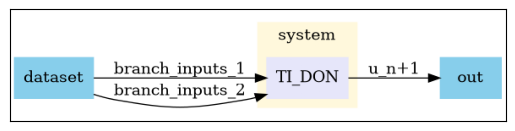

In [34]:
dynamics_model.show()

Checking shape of output

In [35]:
rhs_wrapper = rhs_wrapper.to("cpu")
fxRK4 = fxRK4.to("cpu")  # if fxRK4 is a module

u_t = train_ds.datadict["branch_inputs_1"].to(dtype=torch.float32, device="cpu")
f_t = train_ds.datadict["branch_inputs_2"].to(dtype=torch.float32, device="cpu")

with torch.no_grad():
    du_dt = rhs_wrapper(u_t, f_t)
    u_next = fxRK4(u_t, f_t)
    print("rhs_wrapper:", du_dt.shape)  # (B, 100)
    print("fxRK4:", u_next.shape)  # (B, 100)


/home/pk222/neuromancer/.venv/lib/python3.12/site-packages/torchdiffeq/_impl/misc.py:306: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


rhs_wrapper: torch.Size([96000, 100])
fxRK4: torch.Size([96000, 100])


In [36]:
outputs_new = train_ds.datadict["outputs"].to(dtype=torch.float32, device="cpu")
loss_test = torch.mean((outputs_new - u_next) ** 2)
l2_error = torch.mean(
    torch.norm(outputs_new - u_next_pred, dim=1) / torch.norm(outputs_new, dim=1)
)
print("Test MSE Loss:", loss_test.item())
print("Test Relative L2 Error:", l2_error.item())

Test MSE Loss: 0.0003076493158005178
Test Relative L2 Error: 0.018372833728790283


## Objective and Constraints in NeuroMANCER

We use Mean Squared Error(MSE) for our loss function

$$\sum_{i=1}^{D}(x_i-y_i)^2$$



In [37]:
from neuromancer.problem import Problem
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss

var_y_est = variable("u_n+1")
var_y_true = variable("outputs")

var_loss = (var_y_est == var_y_true) ^ 2
var_loss.name = "residual_loss"
objectives = [var_loss]

loss = PenaltyLoss(objectives, constraints=[])


`Problem` setup using both DeepONets is similar. The Neuromancer library gives you the choice of seamlessly adding any approximator of choice in your `Problem` framework

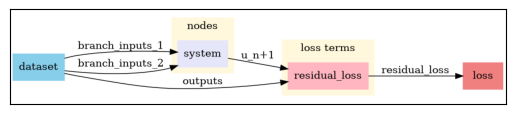

In [38]:
problem = Problem(
    nodes=[dynamics_model],
    loss=loss,
    #   grad_inference=True
)
problem.show()  # graphviz library needed for graph visualization

## Problem Solution in NeuroMANCER

In [ ]:
# result_dir = './'
# epochs = int(500)
# log_iter = 5
# lr = 1e-3
# transition_steps = 2000
# decay_rate = 0.9

### Construct Trainer and solve the problem

In [39]:
from neuromancer.trainer import Trainer
from neuromancer.callbacks import LossHistoryCallback

# define loss history callback using plots
loss_history_callback = LossHistoryCallback(plots_dir=None, show=True)

# define trainer
# trainer = Trainer(
#     problem.to(device),
#     train_data=train_loader,
#     dev_data=dev_loader,
#     test_data=test_loader,
#     optimizer=optimizer,
#     logger=None,
#     callback=loss_history_callback,
#     epochs=epochs,
#     patience=patience,
#     epoch_verbose=epoch_verbose,
#     train_metric="train_loss",
#     dev_metric="dev_loss",
#     test_metric="test_loss",
#     eval_metric="dev_loss",
#     warmup=warmup,
#     device=device,
# )

In [ ]:
epochs = 500
lr = 1e-3

optimizer = torch.optim.Adam(problem.parameters(), lr=lr, weight_decay=1e-4)

trainer = Trainer(
    problem.to(device),
    train_data=train_loader,
    # dev_data=dev_loader,        # optional
    optimizer=optimizer,
    epochs=epochs,
    epoch_verbose=10,
    train_metric="train_loss",
    dev_metric="train_loss",  # or "dev_loss" if you use dev_data
    eval_metric="train_loss",
    warmup=epochs,
    device=device,
)

In [41]:
%%time
best_model = trainer.train()

CPU times: user 42.7 ms, sys: 4.36 ms, total: 47 ms
Wall time: 50.7 ms


/home/pk222/neuromancer/src/neuromancer/dynamics/integrators.py:351: SyntaxWarning: invalid escape sequence '\d'
  """
/home/pk222/neuromancer/src/neuromancer/dynamics/integrators.py:375: SyntaxWarning: invalid escape sequence '\d'
  """


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x75 and 100x128)

In [33]:
# load best trained model
best_outputs = trainer.test(best_model)
problem.load_state_dict(best_model)

<All keys matched successfully>

In [34]:
train_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["train"]]
dev_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["dev"]]
mean_test_loss = best_outputs["mean_test_loss"].detach().cpu().numpy()
print(mean_test_loss)
print(f"len(train_loss_history): {len(train_loss_history)}")
print(f"len(dev_loss_history): {len(dev_loss_history)}")

7.593459e-05
len(train_loss_history): 286
len(dev_loss_history): 286


## Plot loss history w/ mean test loss

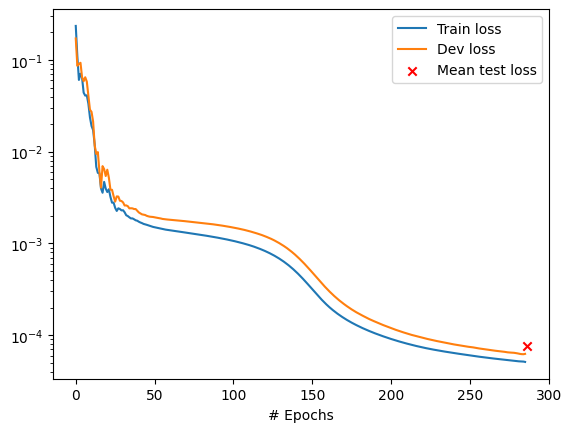

In [35]:
plt.semilogy(train_loss_history, label="Train loss")
plt.semilogy(dev_loss_history, label="Dev loss")
plt.scatter(
    len(train_loss_history), mean_test_loss, label="Mean test loss", c="red", marker="x"
)
plt.xlabel("# Epochs")
plt.legend()
plt.show()

## Compare results on the test data

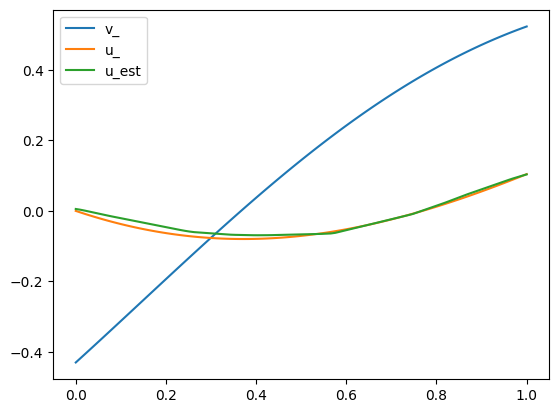

In [36]:
# Evaluate on a test function
k = 211  # k-th test function
v_ = test_datadict.datadict["branch_inputs"][k : k + 1].to(device)  # (1, m)
x_ = test_datadict.datadict["trunk_inputs"][k : k + 1].to(device)  # (1, m, 1)

res = problem.predict({"branch_inputs": v_, "trunk_inputs": x_})

u_true = test_datadict.datadict["outputs"][k].to(device)  # (m,)
u_est = res["g"][0]  # (m,)
grid = x_[0, :, 0].detach().cpu().numpy()

plt.plot(grid, v_[0].detach().cpu().numpy(), label="v_")
plt.plot(grid, u_true.detach().cpu().numpy(), label="u_")
plt.plot(grid, u_est.detach().cpu().numpy(), label="u_est")
plt.legend()


## Symbolic Integral Examples

Evaluate on the function $v(x) = x^2$

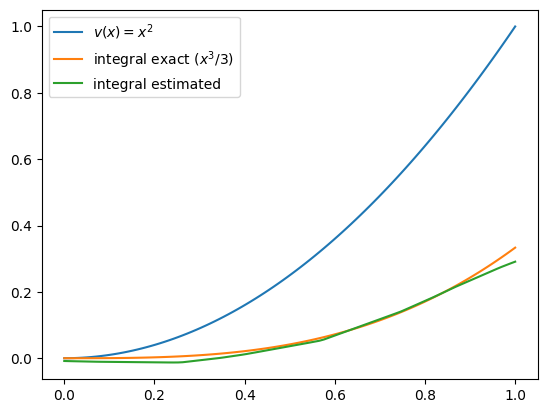

In [37]:
# Evaluate on the function v(x) = x^2

grid = train_datadict.datadict["trunk_inputs"][0]  # (m, 1)
x_ = grid.unsqueeze(0).to(device)  # (1, m, 1)
v_ = torch.pow(grid[:, 0], 2).unsqueeze(0).to(device)  # (1, m)

res = problem.predict({"branch_inputs": v_, "trunk_inputs": x_})

u_true = (1.0 / 3.0) * torch.pow(grid[:, 0], 3)  # (m,)
u_est = res["g"][0]  # (m,)
grid_np = grid[:, 0].detach().cpu().numpy()

plt.plot(grid_np, v_[0].detach().cpu().numpy(), label="$v(x) = x^2$")
plt.plot(grid_np, u_true.detach().cpu().numpy(), label="integral exact ($x^3/3$)")
plt.plot(grid_np, u_est.detach().cpu().numpy(), label="integral estimated")
plt.legend()


Evaluate on the function $v(x) = cos(x)$

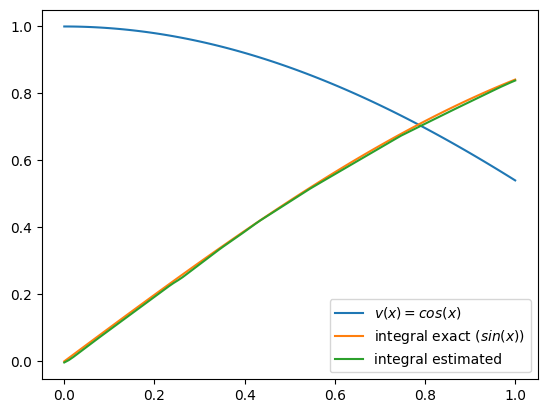

In [38]:
# Evaluate on the function v(x) = cos(x)

grid = train_datadict.datadict["trunk_inputs"][0]  # (m, 1)
x_ = grid.unsqueeze(0).to(device)  # (1, m, 1)
v_ = torch.cos(grid[:, 0]).unsqueeze(0).to(device)  # (1, m)

res = problem.predict({"branch_inputs": v_, "trunk_inputs": x_})

u_true = torch.sin(grid[:, 0])  # (m,)
u_est = res["g"][0]  # (m,)
grid_np = grid[:, 0].detach().cpu().numpy()

plt.plot(grid_np, v_[0].detach().cpu().numpy(), label="$v(x) = cos(x)$")
plt.plot(grid_np, u_true.detach().cpu().numpy(), label="integral exact ($sin(x)$)")
plt.plot(grid_np, u_est.detach().cpu().numpy(), label="integral estimated")
plt.legend()


### Comparison with problem_dde
Conpare the predictions on test data using the `dde.nn.DeepONet`

In [39]:
loss_history_callback_dde = LossHistoryCallback(plots_dir=None, show=True)
optimizer_dde = torch.optim.AdamW(problem_dde.parameters(), lr=lr)

trainer_dde = Trainer(
    problem_dde.to(device),
    train_data=train_loader,
    dev_data=dev_loader,
    test_data=test_loader,
    optimizer=optimizer_dde,
    logger=None,
    callback=loss_history_callback_dde,
    epochs=epochs,
    patience=patience,
    epoch_verbose=epoch_verbose,
    train_metric="train_loss",
    dev_metric="dev_loss",
    test_metric="test_loss",
    eval_metric="dev_loss",
    warmup=warmup,
    device=device,
)

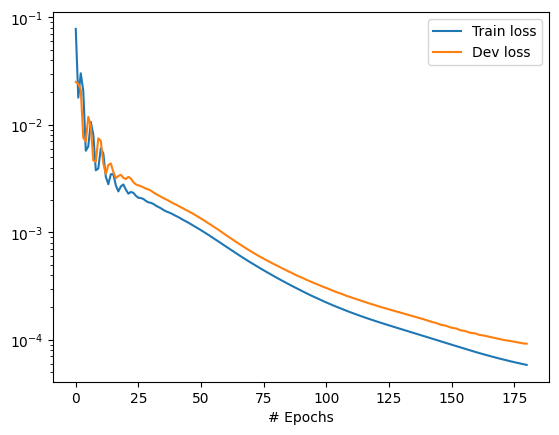

Early stopping!!!


In [40]:
best_model_dde = trainer_dde.train()


In [41]:
best_outputs_dde = trainer_dde.test(best_model_dde)
problem_dde.load_state_dict(best_model_dde)


<All keys matched successfully>

In [42]:
train_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["train"]]
dev_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["dev"]]

train_loss_history_dde = [
    l.detach().cpu().numpy() for l in trainer_dde.loss_history["train"]
]
dev_loss_history_dde = [
    l.detach().cpu().numpy() for l in trainer_dde.loss_history["dev"]
]

mean_test_loss = best_outputs["mean_test_loss"].detach().cpu().numpy()
mean_test_loss_dde = best_outputs_dde["mean_test_loss"].detach().cpu().numpy()
print("baseline test:", mean_test_loss)
print("DeepXDE test:", mean_test_loss_dde)

baseline test: 7.593459e-05
DeepXDE test: 7.38913e-05


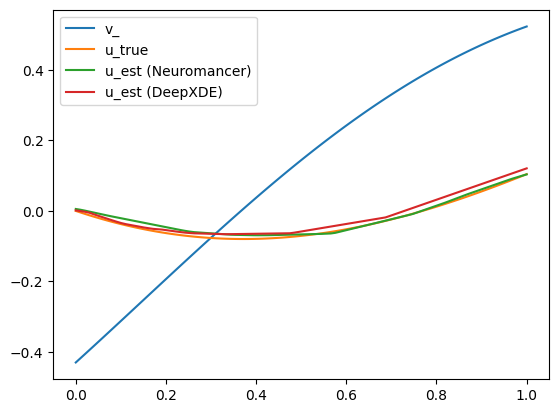

In [43]:
# Compare both models on one test sample
k = 211  # test index
v_ = test_datadict.datadict["branch_inputs"][k : k + 1].to(device)
x_ = test_datadict.datadict["trunk_inputs"][k : k + 1].to(device)

res_base = problem.predict({"branch_inputs": v_, "trunk_inputs": x_})
res_dde = problem_dde.predict({"branch_inputs": v_, "trunk_inputs": x_})

u_true = test_datadict.datadict["outputs"][k].to(device)
u_est_base = res_base["g"][0]
u_est_dde = res_dde["g"][0]
grid = x_[0, :, 0].detach().cpu().numpy()

plt.plot(grid, v_[0].detach().cpu().numpy(), label="v_")
plt.plot(grid, u_true.detach().cpu().numpy(), label="u_true")
plt.plot(grid, u_est_base.detach().cpu().numpy(), label="u_est (Neuromancer)")
plt.plot(grid, u_est_dde.detach().cpu().numpy(), label="u_est (DeepXDE)")
plt.legend()
plt.show()
